In [11]:
import os
import shutil

# Your exact paths based on your terminal
source_dir = r"D:\2do_cuatri_erasmus\intro_computer_vision_and_quality_control\project\data\DATA_Maguire_20180517_ALL"
dest_dir = r"D:\2do_cuatri_erasmus\intro_computer_vision_and_quality_control\project\data\DATA_Maguire_20180517_ALL\final"

# Map exactly where the photos with and without cracks are located
cracked_folders = [r"P\CP", r"W\CW", r"D\CD"]
uncracked_folders = [r"P\UP", r"W\UW", r"D\UD"]

print("Organizing 56,000 images... please wait, the hard drive is working.")

# 1. Copy all cracked photos
print("--> Processing class: Cracked...")
for subfolder in cracked_folders:
    full_path = os.path.join(source_dir, subfolder)
    files = os.listdir(full_path)
    
    for file in files:
        source = os.path.join(full_path, file)
        # Add the initial letter (P, W or D) to prevent duplicate filenames
        dest = os.path.join(dest_dir, "Cracked", f"{subfolder[0]}_{file}")
        shutil.copy2(source, dest)

# 2. Copy all uncracked photos
print("--> Processing class: Non_Cracked...")
for subfolder in uncracked_folders:
    full_path = os.path.join(source_dir, subfolder)
    files = os.listdir(full_path)
    
    for file in files:
        source = os.path.join(full_path, file)
        dest = os.path.join(dest_dir, "Non_Cracked", f"{subfolder[0]}_{file}")
        shutil.copy2(source, dest)

print("Completed! Check your 'final' folder, everything should be ready.")

Organizing 56,000 images... please wait, the hard drive is working.
--> Processing class: Cracked...
--> Processing class: Non_Cracked...
Completed! Check your 'final' folder, everything should be ready.


In [11]:
import os
import shutil

# Your exact paths based on your terminal
source_dir = r"D:\2do_cuatri_erasmus\intro_computer_vision_and_quality_control\project\data\DATA_Maguire_20180517_ALL"
dest_dir = r"D:\2do_cuatri_erasmus\intro_computer_vision_and_quality_control\project\data\DATA_Maguire_20180517_ALL\final"

# Map exactly where the photos with and without cracks are located
cracked_folders = [r"P\CP", r"W\CW", r"D\CD"]
uncracked_folders = [r"P\UP", r"W\UW", r"D\UD"]

print("Organizing 56,000 images... please wait, the hard drive is working.")

# 1. Copy all cracked photos
print("--> Processing class: Cracked...")
for subfolder in cracked_folders:
    full_path = os.path.join(source_dir, subfolder)
    files = os.listdir(full_path)
    
    for file in files:
        source = os.path.join(full_path, file)
        # Add the initial letter (P, W or D) to prevent duplicate filenames
        dest = os.path.join(dest_dir, "Cracked", f"{subfolder[0]}_{file}")
        shutil.copy2(source, dest)

# 2. Copy all uncracked photos
print("--> Processing class: Non_Cracked...")
for subfolder in uncracked_folders:
    full_path = os.path.join(source_dir, subfolder)
    files = os.listdir(full_path)
    
    for file in files:
        source = os.path.join(full_path, file)
        dest = os.path.join(dest_dir, "Non_Cracked", f"{subfolder[0]}_{file}")
        shutil.copy2(source, dest)

print("Completed! Check your 'final' folder, everything should be ready.")

Organizing 56,000 images... please wait, the hard drive is working.
--> Processing class: Cracked...
--> Processing class: Non_Cracked...
Completed! Check your 'final' folder, everything should be ready.


Loading training set...
Found 56092 files belonging to 2 classes.
Using 44874 files for training.
Loading validation set...
Found 56092 files belonging to 2 classes.
Using 11218 files for validation.


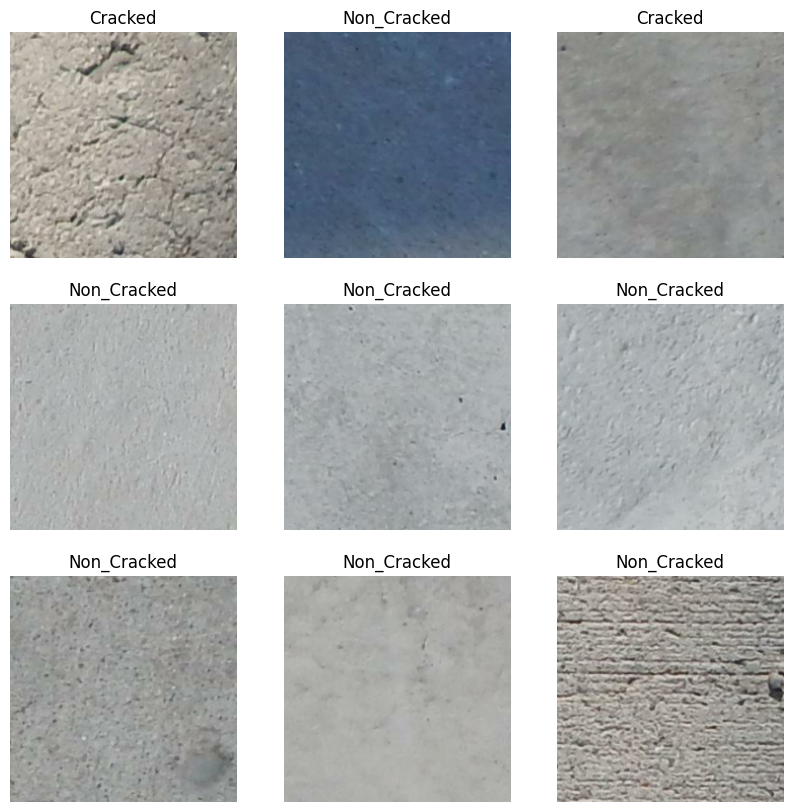

In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Point to the final folder we just populated
data_dir = r"D:\2do_cuatri_erasmus\intro_computer_vision_and_quality_control\project\data\DATA_Maguire_20180517_ALL\final"

image_size = (224, 224) 
batch_size = 32

print("Loading training set...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=image_size,
  batch_size=batch_size)

print("Loading validation set...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=image_size,
  batch_size=batch_size)

class_names = train_dataset.class_names

# Generate the 9-image mosaic
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [13]:
# 1. Optimize data loading (so the GPU doesn't wait for the hard drive)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Downloading the MobileNetV2 base model...")
# 2. Load the pre-trained base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, # Important! Remove the original classification layer
    weights='imagenet' # Use prior knowledge
)

# Freeze the base model so it doesn't forget what it already knows (we only train the final layer)
base_model.trainable = False 

# 3. Create our own classification "head"
inputs = tf.keras.Input(shape=(224, 224, 3))
# MobileNetV2 needs pixels to be between -1 and 1 (specific preprocessing)
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# Pass the images through the base model
x = base_model(x, training=False)

# Convert the feature maps into a flat vector
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Add some Dropout (randomly turns off neurons) to prevent overfitting (memorization)
x = tf.keras.layers.Dropout(0.2)(x)

# Final layer: 1 single neuron that will output 0 or 1
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# Bring it all together
model = tf.keras.Model(inputs, outputs)

# 4. Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

print("Model built and compiled successfully!")

Model built and compiled successfully!


Starting training... (It's only 3 epochs, make yourself comfortable)
Epoch 1/3
1403/1403 [==============================] - 340s 242ms/step - loss: 0.2580 - accuracy: 0.9107 - val_loss: 0.2571 - val_accuracy: 0.9103
Epoch 2/3
1403/1403 [==============================] - 337s 240ms/step - loss: 0.2563 - accuracy: 0.9111 - val_loss: 0.2551 - val_accuracy: 0.9110
Epoch 3/3
1403/1403 [==============================] - 359s 256ms/step - loss: 0.2542 - accuracy: 0.9118 - val_loss: 0.2552 - val_accuracy: 0.9111
Training finished! Generating plots for the report...


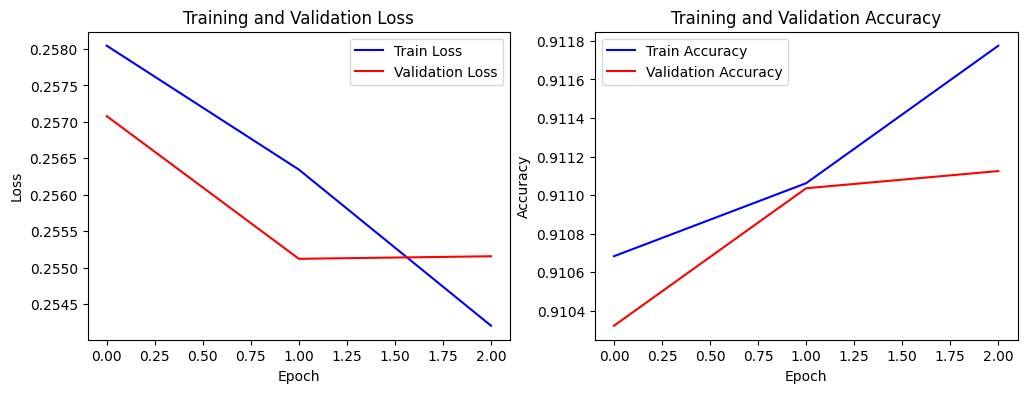

In [20]:
print("Starting training... (It's only 3 epochs, make yourself comfortable)")

# Train the model
history = model.fit(
    train_dataset,
    epochs=3,
    validation_data=val_dataset
)

print("Training finished! Generating plots for the report...")

# Plot the results
plt.figure(figsize=(12, 4))

# 1. Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 2. Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show() # Take a screenshot of this for your Word document!

In [21]:
pip install seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


Evaluating the model on the validation set to generate the Confusion Matrix...

--- Classification Report ---
              precision    recall  f1-score   support

     Cracked       0.88      0.48      0.62      1708
 Non_Cracked       0.91      0.99      0.95      9510

    accuracy                           0.91     11218
   macro avg       0.90      0.74      0.79     11218
weighted avg       0.91      0.91      0.90     11218



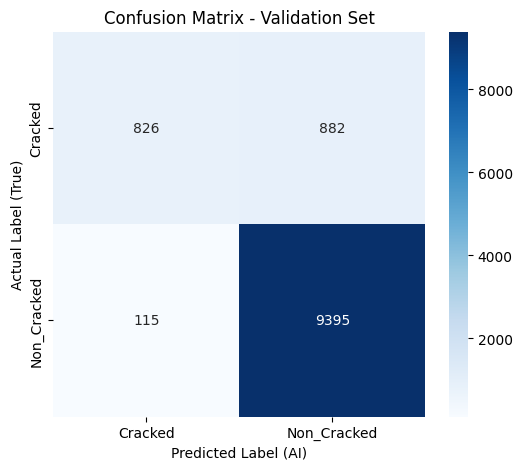

In [22]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Evaluating the model on the validation set to generate the Confusion Matrix...")

# 1. Extract true labels and make predictions
y_true = []
y_pred_probs = []

# We iterate through the validation dataset
for images, labels in val_dataset:
    y_true.extend(labels.numpy())
    # The model outputs a probability between 0 and 1
    preds = model.predict(images, verbose=0) 
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
# If probability is > 0.5, we classify it as 1 (Non_Cracked), else 0 (Cracked)
# Note: TensorFlow sorts classes alphabetically by default. 
# Index 0 = 'Cracked', Index 1 = 'Non_Cracked'
y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# 2. Print the text report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('Actual Label (True)')
plt.xlabel('Predicted Label (AI)')
plt.show() # Screenshot this for the report!